# Solution

First, I'll read the data from the CSV file. I'll use the pd.read_CSV function to do this.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

df = pd.read_csv('bank_customer_churn_dataset/data.csv')

# Preview data
print(df.shape)
df.head(5)

(10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA (Exploratory Data Analysis)

As a first step, I will choose automated report generation via the **ydata_profiling** library.I will generate a report where I will check correlations, missing data, or categories.This is the first preview that can show me what dataset I'm working with and what I need to convert before I put the data into the model for training and testing, and I also need to convert everything to numbers.

In [2]:
from ydata_profiling import ProfileReport

pp = ProfileReport(df)
pp.to_file("Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

When I first analyze the data, I see that I have no missing data in my dataset. Most models can work with this. The problem would be if I wanted to use a LinearRegression model to predict a number. In this case, however, we are doing binary classification and using models that can work with missing data. I also see that these columns are numeric categories:
* customer_id
* credit_score
* age
* tenure
* balance
* estimated_salary

And these columns are nominally categorical:

* country
* gender
* products_number
* credit_card
* active member

### Amount of data

What is the number of rows / columns in the dataset?

In [3]:
print(df.shape)

(10000, 12)


According to what I had written down, there are 12 columns and 10,000 rows.

### Missing data

How many data are misssing?

In [4]:
df_missing = (
    df.isnull().sum()
    .to_frame('count')
    .assign(ratio = lambda dft: dft['count'] / len(df))
)

# Show nicely formatted DataFrame (with highlighted values above 0)
df_missing.style.format({'ratio': '{:.2%}'}).highlight_between(left=0, inclusive='neither')

,count,ratio
customer_id,0,0.00%
credit_score,0,0.00%
country,0,0.00%
gender,0,0.00%
age,0,0.00%
tenure,0,0.00%
balance,0,0.00%
products_number,0,0.00%
credit_card,0,0.00%
active_member,0,0.00%


* in this part I analyze missing values ​​(NaN) in DataFrame. In the code I used **df.isnull().sum()** function which checks if each value is NAN and **sum()** counts TRUE missing values ​​for each column
* next, I used the **.to_frame('count')** transformation in the code, which converts series sum() to DataFrame **count**
* a tiež som použila funkciu **.assign(ratio = lambda dft: dft['count'] / len(df))** , kde **.assign():** pridá nový stĺpec k DataFrame a **lambda dft: dft['count'] / len(df):** vypočíta ratio chýbajúcich hodnôt ku celkovému počtu riadkov v df

### Data types

What are the types of data in individual columns?

In [5]:
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In the data set I see these data types

* 2 columns of type object - strings, which can hide dates, categories and others
* 8 columns of type int64 - integers, but can also represent categories
* 2 columns of type float64 - decimal numbers, we also need to verify their real meaning

### Other analysis columns

Now I will focus on the columns themselves and try to identify unique column values ​​that appear to be nominal.

In [7]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [8]:
df['country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [9]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [10]:
df['credit_card'].unique()

array([1, 0])

In [11]:
df['active_member'].unique()

array([1, 0])

After this analysis, I have an overview of the unique values ​​of all categorical columns.

#### Columns - nominal category

For categorical nominal columns, I will use `OneHotEncoder`, which will create dummy columns. I'll implement this later directly in the pipeline, where we'll set it up for selected columns only. I will group the nominal columns into one variable, which I will call category_nominal_columns.

In [15]:
# Columns representing nominal categories
##category_nominal_columns = ['country','gender','products_number','credit_card','active_member']
##category_nominal_columns 
## It will be to process later

If I didn't use **OneHotEncoder** in the pipeline, let's demonstrate how I would convert such a column. I'll do the demonstration on the **country** column.

In [17]:
##df['country'].unique()

In [18]:
##from pandas.api.types import CategoricalDtype

# Create categorical type
##country_category = CategoricalDtype(categories=['France', 'Spain', 'Germany'], ordered=False)
##country_category

In [19]:
# Convert column to categorical type
##df['country'] = df['country'].astype(country_category)   

# Convert column $WorkArea to dummy variables
##df = pd.get_dummies(df, columns=['country'], prefix='country')

# Preview
##df.head()
##Commented out so as not to change the original dataset

After this transformation, we can see the converted columns at the end of the dataset listing. Let's also show the columns that take on the values ​​0 and 1 to see if I correctly evaluated whether they are nominal category columns.

In [20]:
##df['credit_card'].unique()

In [21]:
##from pandas.api.types import CategoricalDtype

# Create categorical type
##credit_card_category = CategoricalDtype(categories=['0', '1'], ordered=False)
##credit_card_category

In [22]:
# Convert column to categorical type
##df['credit_card'] = df['credit_card'].astype(credit_card_category)   

# Convert column $WorkArea to dummy variables
##df = pd.get_dummies(df, columns=['credit_card'], prefix='credit_card')

# Preview
#df.head()
##Commented out so as not to change the original dataset

After this testing, I figured out that the columns 'credit_card' and 'active_member', which take on the values ​​0 and 1, are considered nominal categories because they represent two distinct groups (e.g. "no" and "yes"). However, if the values ​​are already numeric (0 and 1), I don't need to convert this column in any special way to use it, for example, for a RandomForest model.

**Random Forest** can work directly with binary number columns. I admit I only found this out by googling. Therefore, I am editing my **category_nominal_columns** transformation and removing these columns from there. And I'll mark the previous transformation with ## so that it doesn't run, but remains as a demonstration of what I was thinking.

In [23]:
# Columns representing nominal categories
## category_nominal_columns = ['country','gender','products_number']
## category_nominal_columns
## Processed below

I'll test the **product_number** column just to be sure, which is a number, but according to the analysis it looks like a nominal category.

In [24]:
##df['products_number'].unique()

In [25]:
##from pandas.api.types import CategoricalDtype

# Create categorical type
##products_number_category = CategoricalDtype(categories=['1', '2','3','4'], ordered=False)
##products_number_category

In [26]:
# Convert column to categorical type
##df['products_number'] = df['products_number'].astype(products_number_category)

# Convert column $WorkArea to dummy variables
##df = pd.get_dummies(df, columns=['products_number'], prefix='products_number')

# Preview
##df.head()
#Commented out so it doesn't change the original dataset

After thinking about this column, I realized that this column is an ordinal category. The values ​​have a clear order meaning – more products (e.g. 4) means a higher level of client engagement than fewer products (e.g. 1). There is no need to convert it as the values ​​are numeric and have a meaningful order.

So I modify the transformation with nominal columns again:

In [27]:
# Columns representing nominal categories
category_nominal_columns = ['country','gender']
category_nominal_columns 

['country', 'gender']

### Odstránenie neprediktívnych stĺpcov
In this step, remove the column that shows non-predictivity for the model, which is **customer_id**

In [28]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [29]:
# Delete all unpredictive columns
df.drop(columns=['customer_id'], inplace=True)

# Preview remaining data
df.head(3)

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


## Data splits

### Predictors / target split

In this step, we will perform a basic division of the data into predictors and target variables:

In [32]:
# Predictors / Target split
x = df.iloc[:, :-1].copy()   # x = predictors ; takes all, but last column
y = df.iloc[:, -1].copy()    # y = target ;last column

In [33]:
# Preview predictors
x.head(3)

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57


In [34]:
# Preview predictors
y.head(3)

0    1
1    0
2    1
Name: churn, dtype: int64

### Train / test split

In this step, we will make a basic split into a training and test sample.

In [37]:
from sklearn.model_selection import train_test_split

# Train / Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=333)

## Create model / pipeline

To train my model, I chose the RandomForestClassifier algorithm - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

I chose the model because of these three advantages:
* Robustness and accuracy: Random Forest is resistant to overtraining and often provides very accurate classification results.
* Easy to work with different data: The model can handle different types of data and does not require much preprocessing.
* Ability to work with big data: Random Forest efficiently processes large amounts of data without slowing down performance.

I will create a simple pineline, which I will gradually fill with transformation functions.

In [38]:
from sklearn.pipeline import Pipeline

# Create pipeline
pipeline = Pipeline(steps=[])

The first will be a function using **Onehotencoder** that transforms my columns with nominal categories.

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Helper function, that forces transformers to operate only on some columns, not whole dataframe
def per_column_transformers(transformers_list, remainder='passthrough'):
    return ColumnTransformer(transformers=transformers_list, remainder=remainder, verbose_feature_names_out=False, force_int_remainder_cols=False)


# Create pipeline
pipeline = Pipeline(steps=[
    ('per_column_transformers', per_column_transformers([
        ('convert_nominal_categories', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), category_nominal_columns)
    ]))
])

# Configure pipeline
pipeline.set_output(transform="pandas")  # configure pipeline, that each step should return pd.DataFrame (not np.arrray)

Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False))])

In [40]:
# See original train data
x_train.head(2)

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
9162,665,Germany,Male,63,7,104469.58,1,1,1,25165.36
4794,705,France,Female,39,5,149379.66,2,1,0,96075.55


In [41]:
# Run data through the pipeline
x_train_transformed = pipeline.fit_transform(x_train)

# Check result
x_train_transformed.head(2)

,country_France,country_Germany,country_Spain,gender_Female,gender_Male,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
9162,0.0,1.0,0.0,0.0,1.0,665,63,7,104469.58,1,1,1,25165.36
4794,1.0,0.0,0.0,1.0,0.0,705,39,5,149379.66,2,1,0,96075.55


Let's add the RandomForestClassifier model

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Helper function, that forces transformers to operate only on some columns, not whole dataframe
def per_column_transformers(transformers_list, remainder='passthrough'):
    return ColumnTransformer(transformers=transformers_list, remainder=remainder, verbose_feature_names_out=False, force_int_remainder_cols=False)


# Create pipeline
pipeline = Pipeline(steps=[
    ('per_column_transformers', per_column_transformers([
        ('convert_nominal_categories', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), category_nominal_columns)
    ])),
    ('model', RandomForestClassifier(random_state=42, max_depth=4))
])

# Configure pipeline
pipeline.set_output(transform="pandas")  # configure pipeline, that each step should return pd.DataFrame (not np.arrray)


Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=4, random_state=42))])

We train the model using the fit() function.

In [43]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=4, random_state=42))])

## Model Tuning

First, I will do a single-parameter model tuning using GridSearchCV for demonstration purposes.
Results before using GridSearchCV

In [45]:
# Prediction on test data
y_pred_basic = pipeline.predict(x_test)

# Evaluating model accuracy before tuning
accuracy_basic = accuracy_score(y_test, y_pred_basic)
print(f'Accuracy before tuning: {accuracy_basic:.1%}')

NameError: name 'accuracy_score' is not defined

In [46]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'model__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10 ]
}

# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=10, scoring='accuracy', n_jobs=-1)

# Fit the grid search
grid_search.fit(x_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('per_column_transformers',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('convert_nominal_categories',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['country',
                                                                          'gender'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        RandomForestClassifier(max_depth=4,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='accuracy')

In [47]:
# See best parameters
grid_search.best_params_

{'model__max_depth': 10}

In [48]:
grid_search.best_score_

np.float64(0.86075)

In [49]:
grid_search.best_estimator_

Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [50]:
from sklearn.metrics import accuracy_score

# Get best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on test-set
y_pred = best_model.predict(x_test)

# Evaluate model on test-set using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.1%}')

Accuracy: 86.9%


Now let's try model tuning with multiple parameters

In [51]:
# Define the parameter grid
param_grid = {
    'model__max_depth': [3, 5, 7, 9, 11],
    'model__min_samples_leaf': [1, 2, 4, 6, 8],
    'model__max_features': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=10, scoring='accuracy', n_jobs=-1)

# Fit the grid search
grid_search.fit(x_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('per_column_transformers',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('convert_nominal_categories',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['country',
                                                                          'gender'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        RandomForestClassifier(max_depth=4,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 7, 9, 11],
                         'model__max_features': [0.1, 0.3, 0.5, 0.7, 0.9],
                         'model__min_samples_leaf': [1, 2, 4, 6, 8]},
             scoring='accuracy')

In [52]:
# See best parameters
grid_search.best_params_

{'model__max_depth': 9,
 'model__max_features': 0.7,
 'model__min_samples_leaf': 1}

In [53]:
grid_search.best_score_

np.float64(0.8636250000000001)

In [54]:
grid_search.best_estimator_

Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=9, max_features=0.7,
                                        random_state=42))])

In [55]:
from sklearn.metrics import accuracy_score

# Get best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on test-set
y_pred = best_model.predict(x_test)

# Evaluate model on test-set using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.1%}')

Accuracy: 86.9%


After model tuning, we see that the model gives us an Accuracy of **86.9%**. Let's recall that for the tuning model, Accuracy was **84.4%** So after model tuning, the model accuracy improved by **2.5%**

## Model Serialization

I will save the trained model to disk so that I can easily load it in the future. I will use the **joblib library for this.

In [56]:
import joblib

# saving model after tuning model
joblib.dump(best_model, "best_model.pkl")

# Load model from file
loaded_model = joblib.load("best_model.pkl")
loaded_model

Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=9, max_features=0.7,
                                        random_state=42))])

## Model Evaluation

Let's recall the results of the Accuracy metric, which tells us about the accuracy of the model's prediction from the Model tuning section:
* before model tuning it was **84.4%**
* after model tuning it was **86.9%**

Now I will test the model on test data that the model has not seen before:

In [67]:
from sklearn.metrics import accuracy_score

# Predictions on the test set (y_pred must already be calculated, for example using pipeline.predict)
y_pred = loaded_model.predict(x_test)

# Calculate accuracy on test-set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy on test-set: {accuracy:.2%}')

Accuracy on test-set: 86.85%


According to the result, we can see that the model predicts approximately the results after model tuning both on training and test data that it has never seen.

Evaluation with other metrics:

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Predictions on the test set
y_pred = loaded_model.predict(x_test)

# Easy evaluation on the test set
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print results on the test set
print(f'Accuracy on test-set: {accuracy:.2%}')
print(f'Precision on test-set: {precision:.2%}')
print(f'Recall on test-set: {recall:.2%}')
print(f'F1-Score on test-set: {f1:.2%}')

Accuracy on test-set: 86.85%
Precision on test-set: 85.94%
Recall on test-set: 86.85%
F1-Score on test-set: 85.70%


The results of the model evaluation show that it can correctly predict with 86.85% accuracy whether a client will leave the bank or stay. The model's precision of 85.94% means that there is a high proportion of correct estimates among the predicted departures. A recall of 86.85% indicates that the model can capture the majority of actual client churn. Finally, the F1-score (85.70%) shows a balance between precision and recall, indicating a solid performance of the model for predicting client behavior.

Overall, the model is reliable and usable, although it could still be improved by increasing the F1-score.

### Feature importances

Now I will evaluate the importance of each column as a predictor.

In [61]:
rf_model = pipeline.named_steps['model']  # Prístup k RandomForest modelu
importances = rf_model.feature_importances_  # Získanie feature importances
importances

array([0.01191516, 0.06963242, 0.00337481, 0.01474814, 0.01449205,
       0.01991572, 0.42045403, 0.00335375, 0.04695239, 0.29973846,
       0.00118089, 0.08499268, 0.0092495 ])

In [62]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Helper function, that forces transformers to operate only on some columns, not whole dataframe
def per_column_transformers(transformers_list, remainder='passthrough'):
    return ColumnTransformer(transformers=transformers_list, remainder=remainder, verbose_feature_names_out=False, force_int_remainder_cols=False)


# Create pipeline
pipeline = Pipeline(steps=[
    ('per_column_transformers', per_column_transformers([
        ('convert_nominal_categories', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), category_nominal_columns)
    ]))
])

# Configure pipeline
pipeline.set_output(transform="pandas")  # configure pipeline, that each step should return pd.DataFrame (not np.arrray)

Pipeline(steps=[('per_column_transformers',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('convert_nominal_categories',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])],
                                   verbose_feature_names_out=False))])

In [64]:
# Run data through the pipeline
x_train_transformed = pipeline.fit_transform(x_train)

# Check result
x_train_transformed.head(2)

,country_France,country_Germany,country_Spain,gender_Female,gender_Male,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
9162,0.0,1.0,0.0,0.0,1.0,665,63,7,104469.58,1,1,1,25165.36
4794,1.0,0.0,0.0,1.0,0.0,705,39,5,149379.66,2,1,0,96075.55


In [65]:
x_train_transformed.columns

Index(['country_France', 'country_Germany', 'country_Spain', 'gender_Female',
       'gender_Male', 'credit_score', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')

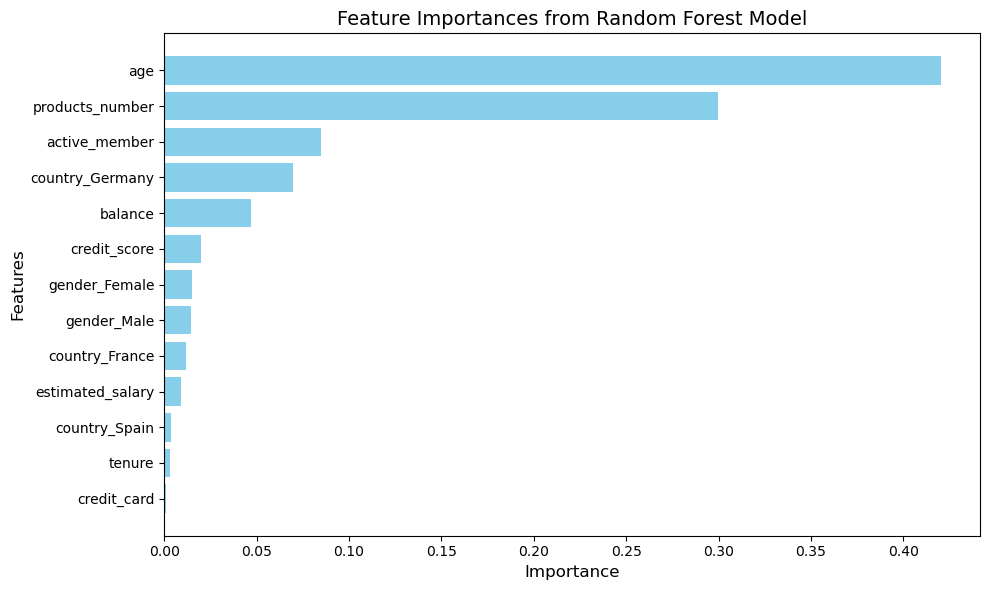

In [69]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# We assume that x.columns contains column names
feature_names = np.array(['country_France', 'country_Germany', 'country_Spain', 'gender_Female',
       'gender_Male', 'credit_score', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary'])

# Importance values
importances = np.array([0.01191516, 0.06963242, 0.00337481, 0.01474814, 0.01449205,
                        0.01991572, 0.42045403, 0.00335375, 0.04695239, 0.29973846,
                        0.00118089, 0.08499268, 0.0092495])

# Prioritization
sorted_indices = np.argsort(importances)[::-1]  # Zoradené zostupne

# Creating a graph
plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_indices], importances[sorted_indices], color='skyblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importances from Random Forest Model', fontsize=14)
plt.gca().invert_yaxis()  # Invertujeme os y, aby najdôležitejšie črty boli hore
plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
import numpy as np

# Column names and importance
feature_names = np.array(['country_France', 'country_Germany', 'country_Spain', 'gender_Female',
'gender_Male', 'credit_score', 'age', 'tenure', 'balance',
'products_number', 'credit_card', 'active_member', 'estimated_salary'])

importances = np.array([0.01191516, 0.06963242, 0.00337481, 0.01474814, 0.01449205,
0.01991572, 0.42045403, 0.00335375, 0.04695239, 0.29973846,
0.00118089, 0.08499268, 0.0092495])

# Create DataFrame
df_importances = pd.DataFrame({
'Feature': feature_names,
'Importance (%)': importances * 100 # Convert to percentage
})

# Sort by importance
df_importances = df_importances.sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

#display result
print(df_importances)

             Feature  Importance (%)
0                age       42.045403
1    products_number       29.973846
2      active_member        8.499268
3    country_Germany        6.963242
4            balance        4.695239
5       credit_score        1.991572
6      gender_Female        1.474814
7        gender_Male        1.449205
8     country_France        1.191516
9   estimated_salary        0.924950
10     country_Spain        0.337481
11            tenure        0.335375
12       credit_card        0.118089


From the graph and the column statement, I can analyze:

* **Most important feature:** age has the highest importance (42%), which means that the model relies the most on age to predict the target variable.
* **Second most important feature:** products_number (29.97%) plays a significant role, indicating that the number of customer products significantly influences the model's decision-making.
* **Less important features:** active_member (8.5%) and country_Germany (6.9%) are moderately important, indicating that customer activity and country have some but not dominant influence.
* **Least important features:** credit_card (0.1%) and country_Spain (0.33%) are almost negligible, indicating that the model considers them almost irrelevant for prediction.
* **Balancing of importance:** Some features, such as gender_Female (1.5%) and estimated_salary (0.9%), have low but non-negligible weights, which may indicate that the model uses a combination of multiple factors in its decision-making.